1. Setup

In [1]:
# =========================================================
# Librerías base
# =========================================================
import os
import sys
import importlib
import time
import joblib
import gc

# Manejo de datos
import pandas as pd
import numpy as np

# Preprocesamiento
from sklearn.preprocessing import StandardScaler

# Métricas
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# Pesos de clase
from sklearn.utils.class_weight import compute_class_weight

# TensorFlow / Keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------
# Detecta la raíz del proyecto
# ---------------------------------------------------------
PROJECT_ROOT = os.path.abspath("..")

# ---------------------------------------------------------
# Agrega la raíz del proyecto al path para importar config
# ---------------------------------------------------------
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

# ---------------------------------------------------------
# Importa configuración del proyecto
# ---------------------------------------------------------
import utils.config as config
importlib.reload(config)

print("FULL_ARTIFACTS_DIR:", config.FULL_ARTIFACTS_DIR)

I0000 00:00:1777834838.286152   15031 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1777834838.366971   15031 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777834840.388266   15031 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


FULL_ARTIFACTS_DIR: /home/bryan_santanderaragon/Proyecto_MBD/data/artifacts/full


2. Cargar artefactos binarios full

In [2]:
# ---------------------------------------------------------
# Carga los datos binarios generados en
# 02_preprocessing_full.ipynb
# ---------------------------------------------------------
X_train = pd.read_parquet(
    os.path.join(config.FULL_ARTIFACTS_DIR, "X_train_full_binary.parquet")
)

X_test = pd.read_parquet(
    os.path.join(config.FULL_ARTIFACTS_DIR, "X_test_full_binary.parquet")
)

y_train = pd.read_csv(
    os.path.join(config.FULL_ARTIFACTS_DIR, "y_train_full_binary.csv")
).squeeze("columns")

y_test = pd.read_csv(
    os.path.join(config.FULL_ARTIFACTS_DIR, "y_test_full_binary.csv")
).squeeze("columns")

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (17871216, 22)
X_test: (4467805, 22)
y_train: (17871216,)
y_test: (4467805,)


3. Revisar distribución de clases

In [3]:
# ---------------------------------------------------------
# Muestra la distribución del target binario
# para ver el desbalance entre normal y ataque
# ---------------------------------------------------------
class_distribution = pd.Series(y_train).value_counts().sort_index()

print("Distribución de clases en y_train:")
print(class_distribution)

Distribución de clases en y_train:
label
0      637104
1    17234112
Name: count, dtype: int64


4. Escalar variables

In [4]:
# ---------------------------------------------------------
# Crea un escalador estándar
# ---------------------------------------------------------
scaler = StandardScaler()

# ---------------------------------------------------------
# Ajusta el scaler con train y transforma train/test
# Luego convertimos a float32 para ahorrar memoria
# ---------------------------------------------------------
X_train_scaled = scaler.fit_transform(X_train).astype("float32")
X_test_scaled = scaler.transform(X_test).astype("float32")

print("Escalado completado.")
print("Shape train escalado:", X_train_scaled.shape)
print("Shape test escalado:", X_test_scaled.shape)

# ---------------------------------------------------------
# Liberar memoria de los DataFrame originales
# ---------------------------------------------------------
del X_train
del X_test
gc.collect()

print("Memoria liberada de X_train y X_test")

Escalado completado.
Shape train escalado: (17871216, 22)
Shape test escalado: (4467805, 22)
Memoria liberada de X_train y X_test


5. Preparar target binario

In [5]:
# ---------------------------------------------------------
# Asegura que el target esté en formato entero compacto
# ---------------------------------------------------------
y_train_enc = y_train.astype("int32")
y_test_enc = y_test.astype("int32")

print("Valores únicos y_train:", np.unique(y_train_enc))
print("Valores únicos y_test:", np.unique(y_test_enc))

Valores únicos y_train: [0 1]
Valores únicos y_test: [0 1]


6. Calcular pesos de clase

In [6]:
# ---------------------------------------------------------
# Calcula pesos de clase para compensar el desbalance
# ---------------------------------------------------------
classes = np.unique(y_train_enc)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_enc
)

class_weights = dict(zip(classes, weights))

print("Pesos de clase:")
print(class_weights)

Pesos de clase:
{np.int32(0): np.float64(14.025352218790024), np.int32(1): np.float64(0.5184838069985851)}


7. Construir el modelo DNN binario

In [7]:
# ---------------------------------------------------------
# Define una red neuronal densa para clasificación binaria
# La salida usa sigmoid porque solo hay 2 clases
# ---------------------------------------------------------
dnn_model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),

    Dense(64, activation="relu"),
    Dropout(0.3),

    Dense(32, activation="relu"),
    Dropout(0.2),

    Dense(1, activation="sigmoid")
])

# ---------------------------------------------------------
# Compila el modelo
# binary_crossentropy porque es clasificación binaria
# ---------------------------------------------------------
dnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

dnn_model.summary()

E0000 00:00:1777834864.344791   15031 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,585 (14.00 KB)

 Trainable params: 3,585 (14.00 KB)

 Non-trainable params: 0 (0.00 B)

8. Configurar EarlyStopping

In [8]:
# ---------------------------------------------------------
# Detiene el entrenamiento si la validación deja de mejorar
# ---------------------------------------------------------
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

9. Entrenar el DNN binario

In [9]:
# ---------------------------------------------------------
# Entrena la red neuronal binaria
# ---------------------------------------------------------
train_start = time.time()

history = dnn_model.fit(
    X_train_scaled,
    y_train_enc,
    validation_split=0.2,
    epochs=20,
    batch_size=128,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

train_elapsed = time.time() - train_start
print(f"✔ DNN binario entrenado en {train_elapsed:.2f} seg")

Epoch 1/20
111696/111696 ━━━━━━━━━━━━━━━━━━━━ 487s 4ms/step - accuracy: 0.9516 - loss: 0.2031 - val_accuracy: 0.9706 - val_loss: 0.1386
Epoch 2/20
111696/111696 ━━━━━━━━━━━━━━━━━━━━ 444s 4ms/step - accuracy: 0.9636 - loss: 0.2019 - val_accuracy: 0.9609 - val_loss: 0.1393
Epoch 3/20
111696/111696 ━━━━━━━━━━━━━━━━━━━━ 439s 4ms/step - accuracy: 0.9646 - loss: 0.2040 - val_accuracy: 0.9653 - val_loss: 0.1230
Epoch 4/20
111696/111696 ━━━━━━━━━━━━━━━━━━━━ 447s 4ms/step - accuracy: 0.9646 - loss: 0.2138 - val_accuracy: 0.9693 - val_loss: 0.1631
Epoch 5/20
111696/111696 ━━━━━━━━━━━━━━━━━━━━ 427s 4ms/step - accuracy: 0.9635 - loss: 0.3096 - val_accuracy: 0.9711 - val_loss: 0.1045
Epoch 6/20
111696/111696 ━━━━━━━━━━━━━━━━━━━━ 437s 4ms/step - accuracy: 0.9624 - loss: 0.2631 - val_accuracy: 0.9714 - val_loss: 0.1014
Epoch 7/20
111696/111696 ━━━━━━━━━━━━━━━━━━━━ 438s 4ms/step - accuracy: 0.9623 - loss: 0.2478 - val_accuracy: 0.9528 - val_loss: 0.1513
Epoch 8/20
111696/111696 ━━━━━━━━━━━━━━━━━━━━ 43

10. Evaluar el modelo

In [10]:
# ---------------------------------------------------------
# Obtiene probabilidades de pertenecer a la clase 1 (attack)
# ---------------------------------------------------------
y_pred_prob = dnn_model.predict(X_test_scaled).ravel()

# ---------------------------------------------------------
# Convierte probabilidad a clase usando umbral 0.5
# ---------------------------------------------------------
y_pred_eval = (y_pred_prob >= 0.5).astype("int32")

# ---------------------------------------------------------
# Verdaderos
# ---------------------------------------------------------
y_test_eval = y_test_enc

# ---------------------------------------------------------
# Métricas principales
# ---------------------------------------------------------
acc = accuracy_score(y_test_eval, y_pred_eval)

precision, recall, f1, _ = precision_recall_fscore_support(
    y_test_eval,
    y_pred_eval,
    average="binary",
    zero_division=0
)

roc_auc = roc_auc_score(y_test_eval, y_pred_prob)

print("Accuracy:", acc)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)
print("ROC-AUC:", roc_auc)

print("\nReporte completo:")
print(classification_report(
    y_test_eval,
    y_pred_eval,
    target_names=["normal", "attack"],
    zero_division=0
))

139619/139619 ━━━━━━━━━━━━━━━━━━━━ 205s 1ms/step
Accuracy: 0.971413031678867
Precision: 0.9973954838556166
Recall: 0.9728967821732197
F1: 0.9849938240411579
ROC-AUC: 0.9903575764811121

Reporte completo:
              precision    recall  f1-score   support

      normal       0.56      0.93      0.70    159276
      attack       1.00      0.97      0.98   4308529

    accuracy                           0.97   4467805
   macro avg       0.78      0.95      0.84   4467805
weighted avg       0.98      0.97      0.97   4467805



11. Construir diccionario de resultados

In [11]:
dnn_results = {
    "model": "DNN Full Binary",
    "accuracy": acc,
    "precision": precision,
    "recall": recall,
    "f1": f1,
    "roc_auc": roc_auc
}

dnn_results

{'model': 'DNN Full Binary',
 'accuracy': 0.971413031678867,
 'precision': 0.9973954838556166,
 'recall': 0.9728967821732197,
 'f1': 0.9849938240411579,
 'roc_auc': 0.9903575764811121}

12. Curvas de entrenamiento

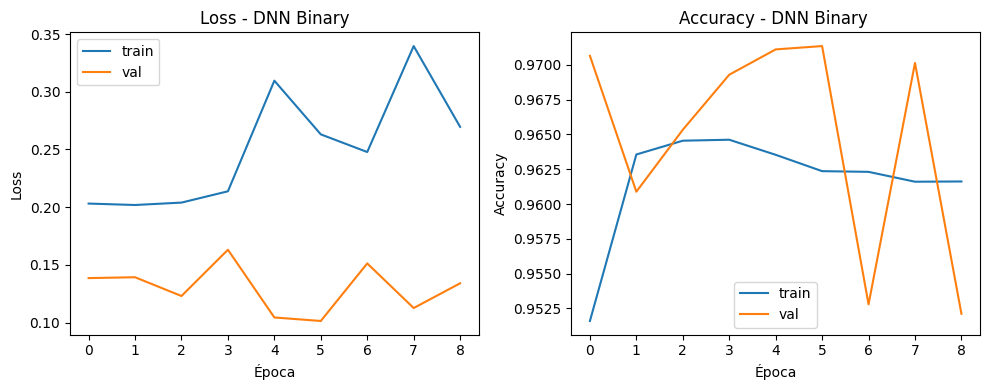

In [12]:
# ---------------------------------------------------------
# Grafica pérdida y accuracy durante el entrenamiento
# ---------------------------------------------------------
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("Loss - DNN Binary")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val")
plt.title("Accuracy - DNN Binary ")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

13. Matriz de confusión binaria

In [13]:
# ---------------------------------------------------------
# Función para graficar matriz de confusión
# ---------------------------------------------------------
def plot_confusion(y_true, y_pred, title, class_names, figsize=(6, 5), annot=True):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=figsize)
    sns.heatmap(
        cm,
        annot=annot,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.title(title)
    plt.xlabel("Predicción")
    plt.ylabel("Valor real")
    plt.show()

14. Guardar modelo y scaler

In [14]:
# ---------------------------------------------------------
# Guarda el modelo DNN binario y el scaler
# ---------------------------------------------------------
dnn_model.save(
    os.path.join(config.FULL_ARTIFACTS_DIR, "dnn_binary_full.keras")
)

joblib.dump(
    scaler,
    os.path.join(config.FULL_ARTIFACTS_DIR, "scaler_binary_full.pkl")
)

print("Modelo y scaler guardados correctamente.")

Modelo y scaler guardados correctamente.


15. Guardar métricas y predicciones

In [15]:
# ---------------------------------------------------------
# Guarda resultados del modelo
# ---------------------------------------------------------
pd.DataFrame([dnn_results]).to_csv(
    os.path.join(config.FULL_ARTIFACTS_DIR, "dnn_binary_results_full.csv"),
    index=False
)

# ---------------------------------------------------------
# Guarda predicciones para análisis posterior
# ---------------------------------------------------------
pd.DataFrame({
    "y_true": y_test_eval,
    "y_pred": y_pred_eval,
    "y_prob": y_pred_prob
}).to_csv(
    os.path.join(config.FULL_ARTIFACTS_DIR, "dnn_binary_predictions_full.csv"),
    index=False
)

print("Resultados y predicciones guardados.")

Resultados y predicciones guardados.


16. Liberar memoria al final

In [16]:
# ---------------------------------------------------------
# Liberar memoria al final del notebook
# ---------------------------------------------------------
for var_name in [
    "X_train_scaled", "X_test_scaled",
    "y_train", "y_test",
    "y_train_enc", "y_test_enc",
    "y_pred_prob", "y_pred_eval"
]:
    if var_name in globals():
        del globals()[var_name]

gc.collect()
print("Memoria liberada.")

Memoria liberada.
